In [4]:
from astropy.modeling.models import BlackBody
import astropy.units as u

import numpy as np

from synphot.blackbody import BlackBody1D
import matplotlib.pyplot as plt

from synphot import units as su

#from astropy.modeling.blackbody import BlackBody1D 

In [121]:
 def estimate_Bbandflux(Teff, M_v, bc_v, lam_low, lam_high):
    c = 3e8
    #sets wavelength limits for model
    freq_low = c/(lam_high*10**(-10))
    freq_high = c/(lam_low*10**(-10))
    
    #introduces some useful constants for Absolute magnetude of the Sun and the Solar Luminosity unit in W
    Lbol_sun=4e33
    M_sun=4.73

    #calculates bolometric magnitude given Absolute V-band Magnitude and bolometric correction from stellar model
    M_bol = M_v + bc_v
    
    #calculates magnitude exponent in conversion to Luminosity
    par_a = (4.8-M_bol)/2.5
    
    #Calculates Luminosity
    L = Lbol_sun*10**par_a

    #lamstep = (lam_high-lam_low)/res
        
    #builds the black body function using unit Kelvin (u.K) and creation 
    #of the black body spectrum range within given wavelength parameters 
    bb = BlackBody1D(temperature=Teff*u.K)
    wav=np.arange(lam_low, lam_high)*u.AA
    
    #print('Frequency: ',wav)
    #calculates the normalized flux (FLAM=f_lambda,u.Watts per Hertz) in each wavelenght using the 
    #bb model wavelength ranges
    flux=bb(wav)#.to(FLAM,
                 #   u.spectral_density(wav)
                 #  )
    print('Flux: ',flux[1])
    plt.plot(wav,flux)
    #integrates using the trapeze method between wavelength limits and scales
    #the result to the luminosity of the star 
    Jy=L*np.trapezoid(flux, x=wav, dx=1,axis=-1)
    
    
    return(Jy)

In [9]:
 def estimate_Bbandflux(Teff, M_v, bc_v, lam_low, lam_high):
    c = 3e8
    #sets wavelength limits for model
    freq_low = c/(lam_high*10**(-10))
    freq_high = c/(lam_low*10**(-10))
    
    #introduces some useful constants for Absolute magnetude of the Sun and the Solar Luminosity unit in W
    Lbol_sun=4e33
    M_sun=4.73

    #calculates bolometric magnitude given Absolute V-band Magnitude and bolometric correction from stellar model
    M_bol = M_v + bc_v
    
    #calculates magnitude exponent in conversion to Luminosity
    par_a = (4.8-M_bol)/2.5
    
    #Calculates Luminosity
    L = Lbol_sun*10**par_a * u.erg / u.s
    print('L = ',L)
    #lamstep = (lam_high-lam_low)/res
        
    #builds the black body function using unit Kelvin (u.K) and creation 
    #of the black body spectrum range within given wavelength parameters 
    bb = BlackBody1D(temperature=Teff*u.K)
    wav=np.arange(freq_low, freq_high,step=1e13)*u.Hz
    wavlam=np.arange(lam_low, lam_high)*u.AA
    
    #print('Frequency: ',wav)
    #calculates the normalized flux (FLAM=f_lambda,u.Watts per Hertz) in each wavelenght using the 
    #bb model wavelength ranges
    flux=bb(wavlam).to(su.FLAM,
                    u.spectral_density(wavlam)
                   )
    print('Flux: ',flux[0])
    plt.plot(wavlam,flux)
    #integrates using the trapeze method between wavelength limits and scales
    #the result to the luminosity of the star 
    Bint = np.trapz(flux, x=wav#, dx=1,axis=-1
                     )
    print('Integrat: ',Bint)
     
    Jy=L*Bint
    
    
    return(Jy)

In [5]:
 def estimate_Bbandflux(Teff, M_v, bc_v, lam_low, lam_high):
    
    #sets wavelength limits for model
    lam_low = lam_low
    lam_high = lam_high
    
    #introduces some useful constants for Absolute magnetude of the Sun and the Solar Luminosity unit in W
    Lbol_sun=4e33
    M_sun=4.73

    #calculates bolometric magnitude given Absolute V-band Magnitude and bolometric correction from stellar model
    M_bol = M_v + bc_v
    
    #calculates magnitude exponent in conversion to Luminosity
    par_a = (4.8-M_bol)/2.5
    
    #Calculates Luminosity
    L = Lbol_sun*10**par_a
    print('L_BOL = ',L)

    #lamstep = (lam_high-lam_low)/res
        
    #builds the black body function using unit Kelvin (u.K) and creation 
    #of the black body spectrum range within given wavelength parameters 
    bb = BlackBody1D(temperature=Teff*u.K)
    wav=np.arange(lam_low, lam_high)*u.AA
    
    #print(wav)
    #calculates the normalized flux (FLAM=f_lambda,u.Watts per Hertz) in each wavelenght using the 
    #bb model wavelength ranges
    flux=bb(wav).to(su.FLAM, u.spectral_density(wav))
    plt.plot(wav,flux)
    #integrates using the trapeze method between wavelength limits and scales
    #the result to the luminosity of the star 
    Jy=L*np.trapz(flux, x=wav, dx=1,axis=-1)
    
    
    return(Jy)

L_BOL =  8.832018932075587e+38
L_FUV =  4.899232390794192e+38 Angstrom FLAM


/tmp/ipykernel_21146/2374808947.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Jy=L*np.trapz(flux, x=wav, dx=1,axis=-1)


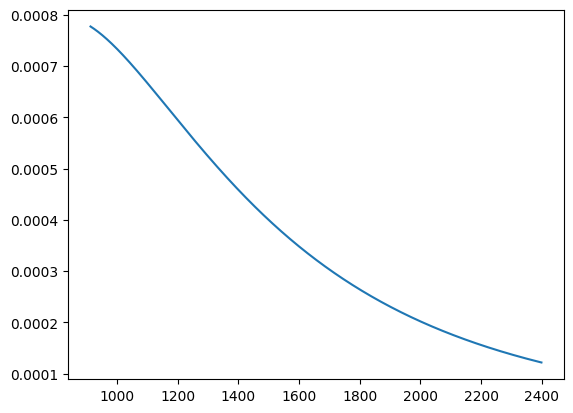

In [8]:
print('L_FUV = ',estimate_Bbandflux(Teff=35000,M_v=-5.5,bc_v=-3.06,lam_low=912,lam_high=2400))

In [24]:
#G0 = 1.6×10^3 ergs s^−1 cm^−2
#sig = 5.67 x 10-5 ergs cm-2 s-1 K-4

Teff = 57000
lam_low = 912
lam_high = 2400
fbol=2e10

bb = BlackBody(temperature = Teff*u.K)
bb1d = BlackBody(temperature = Teff*u.K)

wav=np.arange(lam_low, lam_high)*u.AA

#*(fbol*u.erg*u.s**(-1)*u.cm**(-2))

flux = np.pi*bb1d(wav)
print(flux)


[0.11026353 0.11025771 0.11025159 ... 0.04855677 0.04852878 0.0485008 ] erg / (Hz s sr cm2)


In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord

# RA and Dec in hhmmss.s format

#zet pup
ra_str = "08 03 35.04754"
dec_str = "-40 00 11.3321"

ra_str1 = "08 23 11.8586968392 "
dec_str1 = "-39 07 01.621267032"

#gam2 Vel
ra_str2 = "08 09 31.95013 "
dec_str2 = "-47 20 11.7108 "


dist = 370
dist1 = 335

# Create a SkyCoord object, specifying the units as (hourangle, deg)
c = SkyCoord(ra=ra_str, dec=dec_str, unit=(u.hourangle, u.deg))
c1 = SkyCoord(ra=ra_str1, dec=dec_str1, unit=(u.hourangle, u.deg))
c2 = SkyCoord(ra=ra_str2, dec=dec_str2, unit=(u.hourangle, u.deg))


# Access the RA and Dec in degrees
ra_deg = c.ra.degree
dec_deg = c.dec.degree
ra_deg1 = c1.ra.degree
dec_deg1 = c1.dec.degree
ra_deg2 = c2.ra.degree
dec_deg2 = c2.dec.degree


print(f"RA (deg): {ra_deg}")
print(f"Dec (deg): {dec_deg}")

print(f"RA (deg): {ra_deg1}")
print(f"Dec (deg): {dec_deg1}")

print(f"RA (deg): {ra_deg2}")
print(f"Dec (deg): {dec_deg2}")
print('\n\n')

print('Zet Pup X (as): ',-(ra_deg1-ra_deg)*3600)
print('Zet Pup Y (as): ',-(dec_deg1-dec_deg)*3600)
print('\n')
print('Gam2 Vel X (as): ',-(ra_deg1-ra_deg2)*3600)
print('Gam2 Vel Y (as): ',-(dec_deg1-dec_deg2)*3600)



RA (deg): 120.89603141666667
Dec (deg): -40.00314780555556
RA (deg): 125.79941123682998
Dec (deg): -39.11711701862
RA (deg): 122.38312554166664
Dec (deg): -47.33658633333334



Zet Pup X (as):  -17652.167352587912
Zet Pup Y (as):  -3189.7108329680036


Gam2 Vel X (as):  -12298.628502588019
Gam2 Vel Y (as):  -29590.08953296801
